In [ ]:
# Cell 1 — Install & Import
%pip install -q pandas openpyxl numpy statsmodels arch matplotlib

import pandas as pd
import numpy as np
import statsmodels.api as sm
from arch import arch_model
import matplotlib.pyplot as plt
import warnings
from datetime import date

warnings.filterwarnings('ignore')

In [ ]:
# Cell 2 — Mount Google Drive & Load Data
from google.colab import drive
drive.mount('/content/drive')

# === USER: Update this path to your Stock_Indices.xlsx location ===
DATA_PATH = '/content/drive/MyDrive/Thảo/data/indices/full.xlsx'

dic_df = pd.read_excel(DATA_PATH, sheet_name=None, header=0, usecols=['Date', 'Price'])

for sheet, df in dic_df.items():
    df['Date'] = pd.to_datetime(df['Date'])
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
    df = df.set_index('Date')
    df.index = df.index.date
    df = df.sort_index()
    dic_df[sheet] = df

print(f"Sheets loaded: {list(dic_df.keys())}")
for sheet, df in dic_df.items():
    print(f"  {sheet}: shape={df.shape}, range={df.index.min()} to {df.index.max()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sheets loaded: ['VNI', 'BSE', 'IGPA', 'TWSE', 'FTSE', 'CAC', 'KOSPI', 'Sing', 'BYMA', 'SET', 'Dow', 'S&P500', 'SZSE', 'SSE', 'Shang', 'MIWD00000PUS', 'MIWO00000PUS', 'MSCINA', 'MSCIFE', 'MSCIEU']
  VNI: shape=(2298, 1), range=2017-01-03 to 2026-03-20
  BSE: shape=(2285, 1), range=2017-01-02 to 2026-03-20
  IGPA: shape=(2290, 1), range=2017-01-03 to 2026-03-20
  TWSE: shape=(2242, 1), range=2017-01-03 to 2026-03-20
  FTSE: shape=(2253, 1), range=2017-01-03 to 2026-03-19
  CAC: shape=(2359, 1), range=2017-01-02 to 2026-03-20
  KOSPI: shape=(2260, 1), range=2017-01-02 to 2026-03-20
  Sing: shape=(2365, 1), range=2017-01-02 to 2026-03-20
  BYMA: shape=(2256, 1), range=2017-01-02 to 2026-03-20
  SET: shape=(2241, 1), range=2017-01-04 to 2026-03-20
  Dow: shape=(2318, 1), range=2017-01-03 to 2026-03-20
  S&P500: shape=(2316, 1), range=2017-01-03 to 2026-03-20
  SZS

In [ ]:
# Cell 3 — Configuration
INDICES = ['S&P500', 'SSE', 'MSCINA', 'MSCIFE', 'MSCIEU']

BENCHMARK = 'MIWD00000PUS'

DATE_RANGE = (date.fromisoformat('2017-01-04'), date.fromisoformat('2020-12-31'))

EVENT_DATES = [date.fromisoformat(d) for d in [
    '2017-04-24', '2017-05-02', '2017-05-22', '2017-08-18',
    '2018-01-23', '2018-02-08', '2018-03-23', '2018-04-03',
    '2018-04-17', '2018-05-02', '2018-05-18', '2018-06-19',
    '2018-07-02', '2018-07-11', '2018-08-02', '2018-08-15',
    '2018-08-22', '2018-09-17', '2018-09-25', '2018-12-05',
    '2018-12-14', '2019-01-02', '2019-01-22', '2019-02-08',
    '2019-02-15', '2019-05-06', '2019-05-13', '2019-06-04',
    '2019-07-17', '2019-08-02', '2019-08-06', '2019-08-26',
    '2019-09-03', '2019-10-18', '2019-12-13', '2020-01-15',
    '2020-02-13',
]]

EVENT_WINDOW = 5       # ±5 days around event
ESTIMATION_WINDOW = 61 # 61 trading days for model estimation

print(f"Indices: {INDICES}")
print(f"Benchmark: {BENCHMARK}")
print(f"Date range: {DATE_RANGE[0]} to {DATE_RANGE[1]}")
print(f"Number of events: {len(EVENT_DATES)}")
print(f"Event window: ±{EVENT_WINDOW} days")
print(f"Estimation window: {ESTIMATION_WINDOW} days")

Indices: ['S&P500', 'SSE', 'MSCINA', 'MSCIFE', 'MSCIEU']
Benchmark: MIWD00000PUS
Date range: 2017-01-04 to 2020-12-31
Number of events: 37
Event window: ±5 days
Estimation window: 61 days


In [ ]:
# Cell 4a — Helper Functions

def compute_returns(df: pd.DataFrame, columns: list[str]):
    """Compute percentage returns against last non-null value: (P_t - P_{t-1}) / P_{t-1} * 100"""
    prices = df[columns].copy()
    returns = pd.DataFrame(index=prices.index)
    for col in columns:
        col_prices = prices[col].dropna()
        returns[col] = col_prices.pct_change() * 100
    return returns


def estimate_market_model_ols(returns, index_col, benchmark_col, est_start, est_end):
    """
    OLS regression: r_index = alpha + beta * r_benchmark
    Estimated over [est_start, est_end].
    Returns: (alpha, beta, residual_se)
    """
    est_data = returns.loc[est_start:est_end, [index_col, benchmark_col]].dropna()
    y = est_data[index_col]
    X = sm.add_constant(est_data[benchmark_col])
    model = sm.OLS(y, X).fit()
    alpha = model.params.iloc[0]
    beta = model.params.iloc[1]
    residual_se = np.sqrt(model.mse_resid)
    return alpha, beta, residual_se


def compute_ar_market_adjusted(returns, index_col, benchmark_col):
    """AR = index return - benchmark return (direct subtraction)."""
    return returns[index_col] - returns[benchmark_col]


def compute_ar_market_model(returns, index_col, benchmark_col, alpha, beta):
    """AR = actual return - (alpha + beta * benchmark return)."""
    expected_return = alpha + beta * returns[benchmark_col]
    return returns[index_col] - expected_return


def compute_ar_garch(returns, index_col, benchmark_col, est_start, est_end):
    """
    GARCH(1,1) with mean: r_index = c + beta * r_benchmark.
    Uses arch library ARX model with exogenous regressor.
    Returns: (AR series over full returns, GARCH model residual SE)
    """
    est_data = returns.loc[est_start:est_end, [index_col, benchmark_col]].dropna()
    y = est_data[index_col]
    x_exog = est_data[[benchmark_col]]

    am = arch_model(y, x=x_exog, mean='ARX', lags=0, vol='GARCH', p=1, q=1)
    res = am.fit(disp='off')

    alpha = res.params.get('Const', 0.0)
    beta_bench = res.params.get(benchmark_col, 0.0)
    fitted_mean = alpha + beta_bench * returns[benchmark_col]
    ar = returns[index_col] - fitted_mean

    n_obs = len(res.resid)
    n_params = len(res.params)
    se = float(np.sqrt(np.sum(res.resid ** 2) / (n_obs - n_params)))
    return ar, se


def run_event_study(returns: pd.DataFrame, event_dates: list[date], index_col, benchmark_col,
                    model_type, estimation_window=61, event_window=5):
    """
    Run event study for one index across all event dates.

    model_type: 'am' (market adjusted), 'mm' (market model), 'garch'
    Returns: (ar_df, tstat_df)
    """
    trading_dates = returns.dropna(subset=[index_col, benchmark_col]).index
    ar_dict = {}
    tstat_dict = {}

    for k, event_date in enumerate(event_dates, start=1):
        valid_dates = trading_dates[trading_dates >= event_date]

        if len(valid_dates) == 0:
            continue
        event_idx_date = valid_dates[0]
        event_pos = trading_dates.get_loc(event_idx_date)
        est_end_pos = event_pos - event_window - 1
        est_start_pos = est_end_pos - estimation_window + 1

        if est_start_pos < 0 or est_end_pos < 0:
            continue
        est_start = trading_dates[est_start_pos]
        est_end = trading_dates[est_end_pos]
        ev_start_pos = event_pos - event_window
        ev_end_pos = event_pos + event_window

        if ev_start_pos < 0 or ev_end_pos >= len(trading_dates):
            continue
        # ev_start = trading_dates[ev_start_pos]
        # ev_end = trading_dates[ev_end_pos]

        alpha, beta, ols_se = estimate_market_model_ols(
            returns, index_col, benchmark_col, est_start, est_end
        )

        if model_type == 'am':
            ar_full = compute_ar_market_adjusted(returns, index_col, benchmark_col)
            se = ols_se
        elif model_type == 'mm':
            ar_full = compute_ar_market_model(returns, index_col, benchmark_col, alpha, beta)
            se = ols_se
        elif model_type == 'garch':
            ar_full, se = compute_ar_garch(
                returns, index_col, benchmark_col, est_start, est_end
            )
        else:
            raise ValueError(f"Unknown model_type: {model_type}")

        ev_dates = trading_dates[ev_start_pos:ev_end_pos + 1]
        ar_window = ar_full.loc[ev_dates]

        relative_days = list(range(-event_window, event_window + 1))
        if len(ar_window) == len(relative_days):
            ar_dict[k] = pd.Series(ar_window.values, index=relative_days)
            tstat_dict[k] = pd.Series(ar_window.values / se, index=relative_days)

    ar_df = pd.DataFrame(ar_dict)
    ar_df.index.name = 'relative_day'
    tstat_df = pd.DataFrame(tstat_dict)
    tstat_df.index.name = 'relative_day'
    return ar_df, tstat_df


def build_results_table(ar_df, se_values):
    """Combine AR values and SE into a display-ready DataFrame."""
    ar_section = ar_df.copy()
    ar_section.index = [f"AR(t={d:+d})" for d in ar_section.index]

    se_df = pd.DataFrame(
        {col: se_values.get(col, np.nan) for col in ar_df.columns},
        index=ar_section.index
    )
    se_df.index = [idx.replace('AR', 'SE') for idx in se_df.index]

    tstat_section = ar_df.copy()
    for col in tstat_section.columns:
        se = se_values.get(col, np.nan)
        if se and se > 0:
            tstat_section[col] = tstat_section[col] / se
    tstat_section.index = [f"t(t={d:+d})" for d in ar_df.index]

    sep = pd.DataFrame(
        {col: ['---'] for col in ar_df.columns},
        index=['---']
    )
    result = pd.concat([ar_section, sep, se_df, sep.rename(index={'---': '---2'}), tstat_section])
    return result


def build_all_tables(results_dict, model_label):
    """Build display tables for all indices in a results dict."""
    tables = {}
    for name, (ar_df, tstat_df) in results_dict.items():
        if ar_df.empty:
            continue
        se_values = {}
        for col in ar_df.columns:
            nonzero = tstat_df[col][tstat_df[col] != 0]
            if len(nonzero) > 0:
                se_values[col] = abs(ar_df[col].loc[nonzero.index[0]] / nonzero.iloc[0])
            else:
                se_values[col] = np.nan
        table = build_results_table(ar_df, se_values)
        tables[f"{model_label}_{name}"] = table
    return tables


def export_to_excel(tables_dict, filename):
    """Write result tables to a multi-sheet Excel file."""
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        for sheet_name, df in tables_dict.items():
            safe_name = sheet_name[:31]
            df.to_excel(writer, sheet_name=safe_name)
    print(f"Exported {len(tables_dict)} sheets to {filename}")


def fit_garch_subperiod(returns, index_col, period_start, period_end, max_ar_lags=9):
    """
    Fit AR-GARCH(1,1) model for a sub-period.
    Step 1: Fit with AR(1)-AR(max_ar_lags) + GARCH(1,1)
    Step 2: Re-estimate with only significant AR lags (p < 0.05)
    Returns: (full_result, refined_result)
    """
    sub_returns = returns.loc[period_start:period_end, index_col].dropna()

    full_model = arch_model(
        sub_returns,
        mean='ARX', lags=max_ar_lags,
        vol='GARCH', p=1, q=1
    )
    full_result = full_model.fit(disp='off')

    significant_lags = []
    for i in range(1, max_ar_lags + 1):
        for param_name in [f'y[{i}]', f'AR[{i}]']:
            if param_name in full_result.pvalues.index:
                if full_result.pvalues[param_name] < 0.05:
                    significant_lags.append(i)
                break

    if significant_lags:
        refined_model = arch_model(
            sub_returns,
            mean='ARX', lags=significant_lags,
            vol='GARCH', p=1, q=1
        )
    else:
        refined_model = arch_model(
            sub_returns,
            mean='Constant',
            vol='GARCH', p=1, q=1
        )
    refined_result = refined_model.fit(disp='off')

    return full_result, refined_result

In [ ]:
# Cell 5 — Compute Returns
all_sheets = INDICES + [BENCHMARK]
combined = pd.DataFrame({sheet: dic_df[sheet]['Price'] for sheet in all_sheets})
combined = combined.loc[DATE_RANGE[0]:DATE_RANGE[1]]
returns = compute_returns(combined, all_sheets)

print("=== Returns Summary ===")
print(returns[all_sheets].describe().round(4))
print(f"\nNon-null counts:\n{returns[all_sheets].count()}")
returns.head(10)

=== Returns Summary ===
            VNI       BSE      IGPA      TWSE      FTSE        CAC     KOSPI  \
count  839.0000  987.0000  989.0000  980.0000  976.0000  1019.0000  978.0000   
mean     0.0523    0.0665    0.0086    0.0515    0.0053     0.0276    0.0410   
std      1.0380    1.2043    1.2306    0.9346    0.7806     1.1667    1.1187   
min     -6.2764  -13.1526  -12.9228   -6.3125   -5.5370   -11.6807   -8.3937   
25%     -0.3099   -0.4187   -0.4466   -0.3644   -0.3194    -0.3768   -0.3956   
50%      0.1201    0.0965    0.0068    0.0847    0.0151     0.0649    0.0820   
75%      0.5688    0.6168    0.4885    0.5519    0.3765     0.5249    0.5885   
max      4.9801    8.9749    7.9542    6.3671    6.9957     8.2645    8.6012   

            Sing      BYMA       SET        Dow     S&P500      SZSE  \
count  1014.0000  971.0000  975.0000  1005.0000  1005.0000  972.0000   
mean      0.0052    0.1439   -0.0019     0.0520     0.0585    0.0442   
std       0.9927    2.7253    1.0756   

,VNI,BSE,IGPA,TWSE,FTSE,CAC,KOSPI,Sing,BYMA,SET,Dow,S&P500,SZSE,SSE,Shang,MIWD00000PUS,MIWO00000PUS,MSCINA,MSCIFE,MSCIEU
2017-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-05,0.164518,0.920320,-0.116534,0.766451,0.698106,0.040338,-0.180384,1.164767,0.220393,0.477750,-0.214972,-0.079267,-0.129034,0.209574,0.209574,0.552422,0.479154,-0.012592,1.567111,-0.026028
2017-01-06,0.590403,-0.442775,0.159344,0.150457,0.721166,0.151915,0.351135,0.198510,0.514433,0.027370,0.324182,0.352578,-0.791691,-0.350350,-0.350350,0.025607,0.035905,0.319626,-0.858737,-0.069426
2017-01-09,0.407473,-0.122126,-0.209191,-0.317961,-0.385965,-0.259224,-0.016592,0.563870,0.960748,-0.470894,-0.382793,-0.355731,0.412368,0.536407,0.536407,-0.342115,-0.345466,-0.365360,0.101961,-0.555797
2017-01-10,-0.219758,0.647334,0.275960,0.077282,0.243846,0.054175,-0.178643,0.930472,1.952313,0.512761,-0.160152,0.000000,-0.246327,-0.301775,-0.301775,0.224189,0.150821,0.030413,0.315724,0.113527
2017-01-11,0.894181,0.895368,0.784462,-0.041713,0.299786,0.109353,1.469351,-0.006006,-0.776488,0.052796,0.497343,0.282075,-0.881593,-0.788191,-0.788191,-0.062912,-0.081478,0.256264,-0.324198,0.287858
2017-01-12,-0.029105,0.393325,0.516205,0.689512,0.258192,-0.431100,0.576820,-0.138142,0.570950,-0.260024,-0.317125,-0.215356,-0.824729,-0.556627,-0.556627,0.384705,0.296372,-0.168096,1.033734,-0.626250
2017-01-13,-0.276581,-0.033398,0.028004,-0.333150,-0.344126,1.058895,-0.495894,1.010435,0.990874,0.407945,-0.026494,0.184989,-1.213377,-0.209343,-0.209343,0.232261,0.268582,0.236945,-0.119952,0.919037
2017-01-16,-1.039325,0.183971,-0.235009,-0.922290,-0.824129,-0.666447,-0.607669,-0.595433,1.108795,-0.218379,NaN,NaN,-2.952549,-0.299734,-0.299734,-0.305874,-0.249968,-0.020781,-0.173328,-0.780572
2017-01-17,0.998613,-0.192428,0.135896,0.669369,0.392877,-0.363045,0.373031,0.041930,-0.875258,-0.315562,-0.296494,-0.294557,1.173606,0.172068,0.172068,0.023243,-0.050455,-0.265880,-0.289056,-0.104895


In [ ]:
# Cell 6 — Market Adjusted Model (AM)
results_am = {}

print("=" * 60)
print("MARKET ADJUSTED MODEL — Abnormal Returns")
print("=" * 60)

for col in INDICES:
    print(f"\n--- {col.upper()} ---")
    ar_df, tstat_df = run_event_study(
        returns, EVENT_DATES, col, BENCHMARK,
        model_type='am',
        estimation_window=ESTIMATION_WINDOW,
        event_window=EVENT_WINDOW
    )
    results_am[col] = (ar_df, tstat_df)
    display(ar_df.round(4))

print(f"\nCompleted Market Adjusted model for {len(results_am)} indices.")

MARKET ADJUSTED MODEL — Abnormal Returns

--- S&P500 ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,0.1654,-0.0154,-0.0171,0.3916,-0.2004,0.0212,0.1749,1.2061,0.3117,0.5286,...,-0.3249,0.0785,0.4482,0.1341,0.1435,0.8019,-0.2794,0.1569,0.3728,-0.2286
-4,0.1910,-0.0678,-0.3351,0.2037,0.4328,-0.3211,-0.3528,-1.1838,-0.2382,0.3329,...,0.1783,-0.0096,-0.0019,-0.3841,-0.3122,-0.3495,-0.0402,-0.1925,-0.0117,0.0018
-3,-0.0024,0.1529,-0.6500,0.1155,-0.0822,-1.1386,0.0623,0.2764,0.4600,-0.1621,...,0.0283,0.2177,0.1341,-0.1783,0.1213,0.3453,0.1072,0.0181,-0.2520,0.4769
-2,0.1251,-0.0368,0.6750,-0.1595,-0.0393,2.2793,-0.1106,0.5462,-0.1384,-0.4997,...,-0.4933,-0.1267,-0.3841,0.4496,0.1957,0.3286,-0.2041,-0.0131,0.1934,-0.2630
-1,-0.1203,-0.0477,-0.0578,-0.7765,0.2088,-0.5615,-0.8764,-1.0162,0.4235,0.4080,...,-0.3509,-0.1215,-0.1783,-0.4596,-1.0272,-0.3300,-0.0398,0.1683,-0.1560,0.0355
0,-0.4528,-0.1482,-0.0492,0.1303,-0.2768,-1.3004,-0.3020,0.8104,0.3597,-0.3264,...,0.7776,-0.1865,0.4496,0.8056,0.8019,-0.1672,-0.0733,-0.5714,0.1178,0.0576
1,-0.0154,0.0409,0.0929,-0.0121,-0.2068,1.4536,1.2061,0.7744,-0.3450,0.1393,...,0.0537,0.3756,-0.4596,-0.1280,-0.3495,-0.0742,0.0696,0.0308,0.2905,0.1315
2,-0.0678,-0.0355,0.1918,0.3027,-0.0665,0.2057,-1.1838,-0.2544,-0.3272,0.5311,...,0.2841,-0.5286,0.8056,0.3610,0.3453,0.1497,-0.2177,-0.0961,-0.0214,0.1726
3,0.1529,-0.0537,0.0238,-0.2433,0.5211,-0.0559,0.2764,-0.9644,-0.0205,-0.0044,...,0.0394,0.1987,-0.1280,-0.1453,0.3286,-0.1556,0.1587,0.0079,0.1467,0.0301



--- SSE ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,-1.4339,-2.9132,-0.2760,-1.3668,0.9166,-0.8875,-0.6412,1.5973,0.2973,0.0938,...,1.1198,-0.8161,-0.0464,0.7776,1.0311,1.3188,-0.4950,-0.3249,-1.3394,1.1567
-4,-0.3097,-0.4609,0.4671,0.0984,-0.2757,2.2396,1.3546,-0.8335,0.8717,2.6873,...,1.0352,-0.1524,0.0402,0.0328,0.3738,-0.5969,1.2486,0.2071,0.2370,0.8724
-3,-0.6455,0.1828,0.8967,0.5935,0.9551,3.6940,0.2622,0.3929,-1.2354,-0.0039,...,-0.4887,0.1927,0.7776,-0.0887,-0.6913,-1.0404,-1.4469,0.2271,-0.0486,0.2489
-2,-0.5831,0.4553,-0.1547,-0.4494,-0.1016,-2.8154,-0.2210,0.1916,-0.5132,-2.0862,...,0.5816,0.2539,0.0328,-0.2296,0.3550,-0.5569,-0.4164,-0.0602,0.2480,-0.0462
-1,0.2142,0.2341,-0.7183,1.4443,-0.2119,-1.8856,1.1060,1.0373,-1.9180,-0.0404,...,-0.3685,0.0649,-0.0887,0.9053,2.0513,1.4002,-0.3605,-0.9893,-0.2878,0.2617
0,-2.9132,-0.6167,-1.0494,0.3202,0.7970,1.0281,-1.5991,-1.2877,-2.1180,0.3589,...,-2.3305,0.2641,-0.2296,-2.0559,-1.4661,0.7296,-0.9993,1.2051,-0.6081,-0.4914
1,-0.4609,-0.0954,-0.5373,0.4290,0.2153,-4.0946,-2.1138,-0.5605,0.3759,1.0057,...,-0.7933,-1.0236,0.9053,-0.5241,1.3188,-0.2277,-0.5665,-0.1193,-1.0620,0.3213
2,0.1828,-0.3487,0.0112,-0.5887,-0.4399,-0.4081,1.5973,-0.1410,1.0854,-1.0674,...,-1.5030,0.8826,-2.0559,-0.5805,-0.5969,-0.1886,0.6402,1.1437,-0.3612,2.2904
3,0.4553,-1.2418,1.0066,0.0264,-0.3891,0.6618,-0.8335,0.2973,-0.6369,1.1257,...,0.3346,-1.3567,-0.5241,-0.1936,-1.0404,0.2138,-0.5570,-0.1262,0.6891,0.5107



--- MSCINA ---


...


--- MSCIFE ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,0.2405,-0.2993,-0.7228,0.1724,0.6939,1.2937,-0.4200,2.3184,-0.9602,0.0165,...,0.8211,-0.3810,-0.8273,0.8519,-0.3326,0.6320,-0.7228,-0.4840,-1.3194,1.3772
-4,0.3849,0.5777,0.2789,-1.7788,-0.6121,0.6272,0.4872,-1.0179,0.5653,-0.6247,...,0.1146,0.3759,-0.3658,-0.0167,1.1954,-0.2073,0.3472,0.4920,0.2050,0.3724
-3,-0.2160,0.3948,1.9466,0.2018,-0.7221,1.1604,-0.7115,-0.6710,-1.1735,0.2403,...,-0.9425,-0.0066,0.8519,1.0036,-1.2781,-1.2731,0.0740,-0.1380,0.4416,-0.9459
-2,-0.5948,-0.4244,-0.7197,-0.4679,0.3449,-2.9050,0.0683,0.5109,0.5336,0.3575,...,0.5087,-0.1238,-0.0167,0.4324,0.0986,0.8757,0.7856,-0.4947,-0.6875,-0.4601
-1,1.0822,0.1250,-0.7820,1.2692,-0.4935,0.2146,2.8483,0.9388,-0.0846,-0.2291,...,-0.5925,-0.3561,1.0036,0.8872,2.1943,-0.5050,-0.4391,-0.9559,0.4129,-0.4315
0,-1.3003,0.0370,0.2422,0.1571,0.8238,3.3950,-1.1435,-0.9905,-0.9001,0.0215,...,-1.4028,0.5716,0.4324,-1.2513,-1.9554,1.0699,0.1791,1.2390,-0.5745,0.0236
1,-0.2993,0.0692,-0.3096,-0.2761,0.2735,-1.6433,-1.2679,-0.6195,0.6346,0.9053,...,1.2343,-1.4097,0.8872,0.3581,0.6320,-0.7869,-0.2413,-1.2632,-0.6073,-0.4463
2,0.5777,-0.3980,-0.1557,-1.0699,-0.5818,-1.0431,2.3184,-0.5982,0.3034,-0.9704,...,-0.5920,1.8735,-1.2513,-1.9064,-0.2073,-0.4342,0.2145,0.4879,-0.0238,-0.7406
3,0.3948,-0.5196,-0.0747,0.6116,-0.8410,-0.0245,-1.0179,1.2981,0.4642,-0.4510,...,-0.4539,-0.7355,0.3581,1.1540,-1.2731,0.3230,0.1494,-0.4374,0.2580,-0.6420



--- MSCIEU ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,-0.6141,-0.4167,-0.3816,-0.7729,0.3258,-0.4983,0.2641,1.7209,-0.4877,-0.4076,...,0.4021,-0.5665,-0.0914,-1.1581,0.0833,0.5960,1.1709,0.4174,0.0849,0.0789
-4,-0.7127,0.3758,-0.2925,0.2569,-0.6138,0.3872,-0.0625,0.9628,-0.2341,0.1498,...,-0.5822,-0.3287,0.2181,0.8139,-0.2630,-0.4904,-0.3921,-0.1260,-0.3169,0.2821
-3,0.4133,-0.2731,-0.0074,0.2738,0.2642,1.4355,0.4485,-0.3351,0.3042,-0.0044,...,0.3048,-0.1118,-1.1581,1.1415,0.6118,0.2074,0.2893,-0.0710,-0.0738,-0.3255
-2,-0.4001,0.0329,-0.2535,0.4314,0.0670,-1.9315,0.0061,-0.0732,0.2586,0.4801,...,-0.1286,0.0239,0.8139,-1.6540,-0.1013,0.3164,-0.1688,-0.0462,-0.6994,0.5284
-1,0.1643,-0.3345,-0.1961,0.1066,-0.2291,1.9640,0.0873,1.2349,-0.7263,-0.0080,...,0.2444,0.5790,1.1415,0.0727,0.6923,0.3982,-0.3637,-0.2980,0.2113,0.0779
0,0.8405,0.4201,-0.7360,-0.4210,-0.3354,0.8576,0.8516,-0.8403,0.1331,1.0626,...,-0.6872,-0.1160,-1.6540,-0.8786,-0.2886,0.3084,0.0607,0.6051,-0.0680,0.0614
1,-0.4167,0.1053,0.1366,-0.5345,-0.8001,-1.5973,-2.1410,-0.7096,-0.0545,-0.4117,...,-0.5202,-0.3509,0.0727,0.0529,0.5960,-0.1941,0.1124,0.7630,-0.3822,-0.0779
2,0.3758,0.5913,0.0875,0.1618,-0.7251,-0.0332,1.7209,1.4814,0.2779,-0.0801,...,-0.3540,0.2570,-0.8786,0.0868,-0.4904,-0.3323,0.2780,-0.8702,0.4469,0.2722
3,-0.2731,0.2575,-0.5103,-0.4118,-0.1744,-0.9099,0.9628,0.9318,0.8171,0.1861,...,-0.0128,0.0590,0.0529,-0.5563,0.2074,-0.0434,-0.0018,-0.1208,-0.1401,0.0119



Completed Market Adjusted model for 5 indices.


In [ ]:
# Cell 7 — Market Model (MM)
results_mm = {}

print("=" * 60)
print("MARKET MODEL — Abnormal Returns")
print("=" * 60)

for col in INDICES:
    print(f"\n--- {col.upper()} ---")
    ar_df, tstat_df = run_event_study(
        returns, EVENT_DATES, col, BENCHMARK,
        model_type='mm',
        estimation_window=ESTIMATION_WINDOW,
        event_window=EVENT_WINDOW
    )
    results_mm[col] = (ar_df, tstat_df)
    display(ar_df.round(4))

print(f"\nCompleted Market Model for {len(results_mm)} indices.")

MARKET MODEL — Abnormal Returns

--- S&P500 ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,0.1669,0.0220,0.0418,0.4164,-0.2299,0.0109,0.1764,0.8206,-0.1841,0.6073,...,-0.2915,-0.0087,0.3827,0.1622,-0.1153,0.7076,-0.6932,0.0559,0.3737,-0.3140
-4,0.2060,-0.0599,-0.2914,0.1994,0.4196,-0.2630,-0.1058,-1.0417,-0.1589,0.0404,...,0.2583,-0.0764,0.0033,-0.3075,-0.2442,-0.3751,-0.0403,-0.1672,-0.0302,0.0291
-3,0.0090,0.1553,-0.7033,0.1375,-0.1100,-1.0343,0.0433,0.4238,0.3059,-0.3017,...,-0.0292,0.1496,0.1757,-0.0992,-0.0604,0.2487,-0.1697,0.0444,-0.2458,0.4227
-2,0.1274,-0.0374,0.6799,-0.1502,-0.0532,2.2869,-0.0930,0.3347,-0.1156,-0.4314,...,-0.4191,-0.1796,-0.2936,0.5997,0.2143,0.0686,-0.2328,-0.0490,0.1809,-0.3352
-1,-0.1088,-0.0299,0.0172,-0.7381,0.1978,-0.5778,-0.4977,-0.7019,0.2623,0.4194,...,-0.3937,-0.1205,-0.0852,-0.1008,-0.7303,-0.4494,-0.1557,0.0769,-0.1512,-0.0546
0,-0.4609,-0.1280,0.0145,0.1563,-0.2905,-1.2162,0.1125,0.6973,0.0879,-0.2313,...,0.5657,-0.1490,0.6143,0.6953,0.7057,-0.0508,-0.0120,-0.6466,0.1204,0.0520
1,-0.0131,0.0396,0.1246,0.0020,-0.2288,1.4382,0.8583,0.6776,-0.5201,0.2252,...,-0.0793,0.3465,-0.0843,-0.1927,-0.3892,-0.3895,-0.1312,-0.0594,0.2766,0.0978
2,-0.0585,-0.0239,0.2213,0.3014,-0.0891,0.1448,-1.0571,-0.4934,-0.2720,0.2241,...,0.2079,-0.5470,0.7076,0.0928,0.2472,-0.1638,-0.2066,-0.1071,-0.0306,0.1920
3,0.1634,-0.0240,0.0777,-0.2230,0.5118,-0.0822,0.4079,-0.6482,0.2368,-0.1705,...,-0.1255,0.1547,-0.1800,-0.0982,0.0964,-0.2369,0.0959,0.0231,0.1660,-0.0431



--- SSE ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,-0.8941,-1.6774,0.3771,-1.6480,0.8594,-0.8896,-0.6384,1.3558,1.1939,0.1184,...,1.2318,-0.6215,0.0889,0.8025,1.6704,1.3588,0.4830,0.1634,-1.2854,1.5089
-4,-0.7366,0.0254,0.8465,0.6266,0.0541,1.5332,0.6836,-1.0869,0.7739,2.4209,...,1.2197,0.0314,0.1211,0.0292,0.1225,-0.3912,1.1587,0.2145,0.5820,0.8782
-3,-0.8164,0.1749,-0.4700,0.3887,0.9385,2.5124,0.3213,0.9346,-0.9296,-0.0606,...,-0.5182,0.3772,0.8304,-0.0938,-0.2620,-0.4536,-0.8227,0.2305,-0.0747,0.5054
-2,-0.1008,0.3559,-0.4723,-0.3002,0.2096,-3.0022,-0.2623,0.3023,-0.5134,-1.5198,...,0.7571,0.4304,0.0480,-0.2765,0.2384,-0.2981,-0.4326,0.1800,0.5038,0.2657
-1,0.0329,0.0845,0.2263,0.7808,0.1695,-1.8265,0.0739,0.4144,-1.5998,0.2695,...,-0.3751,0.2129,-0.0755,0.7355,1.1766,1.3695,-0.1518,-0.5372,-0.2920,0.6285
0,-1.6833,-0.4185,-0.3092,0.0034,1.1160,0.0537,-2.7294,-0.9639,-1.6084,0.2747,...,-2.6006,0.3928,-0.2715,-1.9494,-1.2698,0.4382,-1.2481,1.5951,-0.5804,-0.3844
1,0.0168,-0.2571,-0.3733,0.4459,0.3344,-4.0446,-1.1527,-0.2730,0.7180,0.9368,...,-0.9404,-0.8597,0.7012,-0.4445,1.3613,0.4885,-0.1384,0.3280,-0.7850,0.5146
2,0.1645,-0.2940,0.1357,-0.1443,-0.3348,0.1104,1.2566,0.1385,1.0292,-0.4766,...,-1.5618,1.0408,-1.8954,-0.3810,-0.3954,0.5231,0.5211,1.2894,-0.1563,2.4643
3,0.3453,-0.8848,1.5715,-0.1322,0.0314,0.8241,-1.1875,1.1395,-1.0424,1.4801,...,0.2357,-1.1849,-0.3992,-0.1798,-0.4735,0.3835,-0.4853,-0.0802,0.6660,0.5407



--- MSCINA ---


...


--- MSCIFE ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,0.4729,-0.0161,-0.5403,0.0307,0.6568,1.2951,-0.4497,2.0450,-0.1593,-0.1485,...,0.5118,-0.1591,-0.6583,0.6556,0.4437,0.6632,0.7086,0.1537,-1.3174,1.8299
-4,0.2455,0.5954,0.3743,-1.4985,-0.6481,0.5400,-0.0670,-1.3017,0.4180,-0.1502,...,-0.4286,0.5187,-0.4502,-0.3892,0.8681,0.0452,0.2724,0.2985,0.6054,0.0103
-3,-0.2569,0.3634,1.4864,0.0998,-0.7590,1.0133,-0.6974,-0.2549,-0.9359,0.4515,...,-0.7946,0.1413,0.6370,0.6218,-0.7622,-0.5119,1.0066,-0.3386,0.3340,-0.7184
-2,-0.3845,-0.4828,-0.8460,-0.3853,0.3089,-2.9269,0.0042,0.5475,0.4794,0.2104,...,-0.0054,-0.0346,-0.4070,-0.2071,-0.0618,1.1990,0.8147,-0.2857,-0.4092,-0.1022
-1,1.0373,0.2314,-0.5068,0.9281,-0.5292,0.2237,2.0129,0.3295,0.1648,-0.2782,...,-0.5184,-0.4753,0.6041,-0.5106,1.0944,-0.5682,-0.0927,-0.3809,0.3353,0.0553
0,-0.8025,0.1654,0.4523,-0.0033,0.7878,3.2740,-2.0554,-0.7663,-0.4683,-0.1718,...,-0.4784,0.3114,-0.2238,-0.9448,-1.7281,0.6587,-0.1197,1.7069,-0.6084,-0.1006
1,-0.0907,0.0043,-0.2827,-0.2624,0.2370,-1.6353,-0.5516,-0.4271,0.9068,0.7278,...,1.7620,-1.4124,-0.5239,0.4985,0.6687,0.1470,0.4147,-0.6963,-0.3000,-0.3672
2,0.5955,-0.3467,-0.1414,-0.8333,-0.6183,-0.9762,2.0212,-0.1285,0.1957,-0.4708,...,-0.3495,1.8295,-0.9656,-1.0264,0.0264,0.4937,0.0985,0.5333,0.1848,-0.7073
3,0.3773,-0.3059,0.0797,0.5337,-0.8767,-0.0024,-1.3253,0.6851,0.0234,-0.1942,...,0.2346,-0.6806,0.4785,0.8885,-0.5865,0.5274,0.3026,-0.5643,0.1545,-0.9472



--- MSCIEU ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,-0.6932,-0.5226,-0.4769,-0.6346,0.4003,-0.3992,0.3388,1.6087,0.1262,-0.5629,...,0.3769,-0.5179,-0.0392,-1.1402,0.1919,0.6381,1.1386,0.2184,0.1212,-0.0093
-4,-0.6766,0.3594,-0.3682,0.3212,-0.5066,0.2463,-0.3536,0.8427,-0.3268,0.4289,...,-0.6193,-0.2861,0.2530,0.8207,-0.2409,-0.4257,-0.4056,-0.0655,-0.4838,0.4783
-3,0.4189,-0.2729,0.0420,0.4051,0.3421,1.1327,0.5537,0.0817,0.4984,0.0959,...,0.3029,-0.0687,-1.1321,1.1477,0.7000,0.3238,0.2632,-0.0083,0.0185,-0.3351
-2,-0.4724,0.0421,-0.2793,0.5303,0.1726,-1.8954,0.0568,0.0524,0.2354,0.3370,...,-0.1643,0.0625,0.8280,-1.6641,-0.0661,0.3883,-0.1835,-0.1114,-0.8040,0.4733
-1,0.1710,-0.3809,-0.3122,0.2797,-0.1176,2.0839,-0.3999,0.8651,-0.5234,-0.0846,...,0.2388,0.6019,1.1550,0.0145,0.6539,0.4307,-0.3824,-0.4774,0.2882,-0.0222
0,0.6793,0.3664,-0.8375,-0.2795,-0.2291,0.6255,0.3111,-0.5707,0.4719,0.8880,...,-0.6493,-0.1038,-1.6580,-0.8288,-0.2230,0.3055,0.0500,0.4591,-0.0134,0.1746
1,-0.4883,0.1167,0.0764,-0.4235,-0.7107,-1.4805,-1.5460,-0.4645,0.1654,-0.5755,...,-0.5027,-0.3192,0.0173,0.0921,0.6466,-0.0602,0.0898,0.5861,-0.5016,-0.0357
2,0.3632,0.5636,0.0301,0.2338,-0.6370,0.2432,1.6090,1.9392,0.2148,0.2160,...,-0.3510,0.2855,-0.8185,0.1728,-0.4243,-0.1989,0.2650,-0.8843,0.3779,0.3304
3,-0.2748,0.1750,-0.5992,-0.2847,-0.0596,-0.7549,0.8438,0.5592,0.5059,0.3174,...,0.0129,0.0950,0.1017,-0.5428,0.3090,0.0163,-0.0181,-0.0811,-0.0499,0.1882



Completed Market Model for 5 indices.


In [ ]:
# Cell 8 — GARCH Model (G) — Event Study
results_garch = {}

print("=" * 60)
print("GARCH(1,1) MODEL — Abnormal Returns")
print("=" * 60)
print("(Plain GARCH(1,1) with ARX(0) mean, no GARCH-M)")

for col in INDICES:
    print(f"\n--- {col.upper()} ---")
    try:
        ar_df, tstat_df = run_event_study(
            returns, EVENT_DATES, col, BENCHMARK,
            model_type='garch',
            estimation_window=ESTIMATION_WINDOW,
            event_window=EVENT_WINDOW
        )
        results_garch[col] = (ar_df, tstat_df)
        display(ar_df.round(4))
    except Exception as e:
        print(f"  GARCH estimation failed for {col}: {e}")
        results_garch[col] = (pd.DataFrame(), pd.DataFrame())

print(f"\nCompleted GARCH model for {len(results_garch)} indices.")

GARCH(1,1) MODEL — Abnormal Returns
(Plain GARCH(1,1) with ARX(0) mean, no GARCH-M)

--- S&P500 ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,0.1776,0.0240,0.0647,0.3812,-0.2303,0.0083,0.1754,0.9673,0.0125,0.6398,...,-0.2915,-0.0108,0.3789,0.1546,-0.0744,0.7133,-0.6819,0.0592,0.3737,-0.3046
-4,0.1829,-0.0715,-0.2825,0.2481,0.4177,-0.2740,-0.2377,-1.0712,-0.1978,0.0432,...,0.2583,-0.0791,-0.0013,-0.3152,-0.2610,-0.3713,-0.0413,-0.1745,-0.0301,0.0183
-3,-0.0051,0.1412,-0.7839,0.1102,-0.1105,-1.0510,0.0532,0.3926,0.3625,-0.2867,...,-0.0292,0.1469,0.1707,-0.1069,-0.0331,0.2544,-0.1625,0.0370,-0.2458,0.4265
-2,0.1361,-0.0529,0.6531,-0.1408,-0.0551,2.2821,-0.1026,0.4233,-0.1313,-0.3997,...,-0.4191,-0.1828,-0.2992,0.5920,0.2063,0.0787,-0.2330,-0.0512,0.1809,-0.3282
-1,-0.1233,-0.0370,0.0551,-0.8129,0.1956,-0.5797,-0.6998,-0.7889,0.3219,0.4465,...,-0.3937,-0.1254,-0.0909,-0.1087,-0.7875,-0.4431,-0.1533,0.0794,-0.1513,-0.0444
0,-0.4262,-0.1339,0.0419,0.1174,-0.2924,-1.2305,-0.1087,0.7530,0.1928,-0.1976,...,0.5658,-0.1552,0.6077,0.6878,0.7179,-0.0507,-0.0148,-0.6455,0.1204,0.0470
1,-0.0046,0.0237,0.1225,-0.0023,-0.2299,1.4362,1.0436,0.7279,-0.4548,0.2583,...,-0.0793,0.3425,-0.0934,-0.2002,-0.3870,-0.3780,-0.1263,-0.0570,0.2766,0.0980
2,-0.0673,-0.0338,0.2171,0.3414,-0.0901,0.1484,-1.1248,-0.3957,-0.3010,0.2257,...,0.2079,-0.5514,0.7042,0.0855,0.2598,-0.1523,-0.2079,-0.1114,-0.0306,0.1827
3,0.1514,-0.0255,0.0962,-0.2455,0.5095,-0.0828,0.3376,-0.7358,0.1251,-0.1576,...,-0.1255,0.1512,-0.1839,-0.1058,0.1326,-0.2315,0.0967,0.0166,0.1659,-0.0359



--- SSE ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,-0.9020,-1.7284,0.3770,-1.6479,0.8507,-0.8892,-0.7241,1.4360,0.6894,0.0657,...,1.2308,-0.6400,0.0649,0.7789,1.6703,1.3580,0.4827,0.1687,-1.2864,1.4391
-4,-0.7275,-0.0064,0.8465,0.6269,0.0555,1.5340,0.8065,-0.9998,0.7913,2.5178,...,1.2188,0.0138,0.0884,-0.0068,0.1225,-0.3906,1.1615,0.2163,0.5760,0.5744
-3,-0.8118,0.1557,-0.4700,0.3888,0.9309,2.5135,0.2182,0.5608,-1.1240,-0.0715,...,-0.5196,0.3595,0.7932,-0.1304,-0.2621,-0.4498,-0.8220,0.2323,-0.0744,0.3709
-2,-0.1077,0.3392,-0.4723,-0.3000,0.2105,-3.0017,-0.3343,0.1783,-0.5472,-1.8511,...,0.7562,0.4134,0.0047,-0.3311,0.2384,-0.2970,-0.4300,0.1834,0.4993,0.1686
-1,0.0377,0.0690,0.2263,0.7808,0.1722,-1.8261,0.3085,0.7157,-1.8007,0.0701,...,-0.3764,0.1983,-0.1190,0.6278,1.1766,1.3680,-0.1498,-0.5322,-0.2920,0.5685
0,-1.7033,-0.4429,-0.3093,0.0035,1.1171,0.0547,-2.4644,-1.2114,-1.9098,0.2780,...,-2.6024,0.3799,-0.3239,-1.9379,-1.2698,0.4346,-1.2448,1.5997,-0.5810,-0.6199
1,0.0100,-0.2723,-0.3734,0.4461,0.3304,-4.0443,-1.5350,-0.4995,0.5045,0.9322,...,-0.9419,-0.8756,0.6228,-0.4446,1.3613,0.4933,-0.1370,0.3329,-0.7898,0.3375
2,0.1664,-0.3147,0.1356,-0.1440,-0.3392,0.1105,1.2772,-0.0833,1.0248,-0.8205,...,-1.5631,1.0254,-1.9154,-0.3294,-0.3954,0.5279,0.5240,1.2922,-0.1599,2.2740
3,0.3488,-0.9133,1.5714,-0.1321,0.0352,0.8244,-1.1627,0.5915,-0.8635,1.2578,...,0.2343,-1.2014,-0.4248,-0.2083,-0.4736,0.3838,-0.4830,-0.0782,0.6662,0.2533



--- MSCINA ---


...


--- MSCIFE ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,0.4959,-0.0155,-0.5387,0.0167,0.6569,1.2980,-0.4636,2.0414,-0.1469,-0.3455,...,0.4824,-0.1302,-0.6710,0.6728,0.1914,0.6778,0.7461,0.1215,-1.3131,1.7421
-4,0.2335,0.5971,0.3757,-1.4804,-0.6481,0.5537,-0.0708,-1.3049,0.3817,-0.1681,...,-0.4812,0.5407,-0.4368,-0.3585,1.0693,0.0147,0.2626,0.2947,0.4754,0.0556
-3,-0.2596,0.3654,1.4870,0.0889,-0.7590,1.0343,-0.7121,-0.2817,-0.9524,0.3599,...,-0.7787,0.1637,0.6638,0.6532,-0.9075,-0.6460,1.0284,-0.3422,0.3752,-0.7694
-2,-0.3635,-0.4807,-0.8449,-0.3822,0.3089,-2.9212,-0.0090,0.5335,0.4479,0.0184,...,-0.0551,-0.0173,-0.3621,-0.1561,0.0708,1.1541,0.8082,-0.3033,-0.4981,-0.1745
-1,1.0342,0.2328,-0.5051,0.8990,-0.5293,0.2256,2.0145,0.3373,0.1488,-0.4426,...,-0.5098,-0.4762,0.6499,-0.4018,1.6131,-0.5344,-0.0892,-0.4109,0.3664,-0.0380
0,-0.7546,0.1668,0.4540,-0.0186,0.7878,3.2918,-2.0524,-0.7866,-0.4749,-0.3766,...,-0.3853,0.2982,-0.1515,-0.9658,-1.7548,0.7634,-0.1365,1.6805,-0.5920,-0.0941
1,-0.0699,0.0065,-0.2814,-0.2646,0.2370,-1.6333,-0.5798,-0.4464,0.8920,0.5274,...,1.8157,-1.4031,-0.3738,0.4902,0.7203,-0.0223,0.4278,-0.7261,-0.3986,-0.3940
2,0.5983,-0.3450,-0.1401,-0.8185,-0.6183,-0.9814,2.0124,-0.1572,0.1615,-0.4817,...,-0.3242,1.8352,-0.9903,-1.0911,-0.0029,0.3256,0.0874,0.5213,0.1194,-0.7266
3,0.3768,-0.3049,0.0813,0.5246,-0.8767,-0.0021,-1.3339,0.6931,-0.0279,-0.2730,...,0.3043,-0.6663,0.4707,0.9110,-0.8020,0.5067,0.2999,-0.5704,0.1943,-0.9112



--- MSCIEU ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,-0.6786,-0.5200,-0.4768,-0.6414,0.4027,-0.3991,0.3775,1.6533,0.1108,-0.5476,...,0.4012,-0.5228,-0.0392,-1.1465,0.1615,0.6200,1.1424,0.1980,0.1281,-0.0080
-4,-0.7241,0.3548,-0.3674,0.3606,-0.5051,0.2469,-0.2358,0.8879,-0.3056,0.4347,...,-0.5925,-0.2904,0.2530,0.8117,-0.2425,-0.4472,-0.4089,-0.0365,-0.4513,0.4987
-3,0.3878,-0.2788,0.0470,0.4027,0.3444,1.1336,0.5859,0.0802,0.5047,0.1056,...,0.3225,-0.0731,-1.1321,1.1386,0.6764,0.2944,0.2646,0.0211,0.0184,-0.3285
-2,-0.4615,0.0355,-0.2768,0.5481,0.1742,-1.8951,0.1007,0.0763,0.2529,0.3520,...,-0.1378,0.0586,0.8280,-1.6773,-0.0721,0.3657,-0.1864,-0.1063,-0.7793,0.4769
-1,0.1394,-0.3831,-0.3128,0.2511,-0.1162,2.0841,-0.2397,0.9320,-0.5175,-0.0710,...,0.2591,0.5996,1.1550,-0.0104,0.6724,0.4141,-0.3838,-0.4941,0.2901,-0.0217
0,0.7380,0.3648,-0.8376,-0.2883,-0.2276,0.6262,0.4828,-0.5593,0.4708,0.9038,...,-0.6380,-0.1050,-1.6580,-0.8273,-0.2391,0.2943,0.0456,0.4487,-0.0087,0.1894
1,-0.4778,0.1099,0.0777,-0.4133,-0.7087,-1.4804,-1.6196,-0.4510,0.1704,-0.5600,...,-0.4871,-0.3224,0.0173,0.0911,0.6355,-0.0922,0.0899,0.5699,-0.4751,-0.0256
2,0.3419,0.5599,0.0315,0.2684,-0.6349,0.2430,1.6881,1.9342,0.2345,0.2215,...,-0.3325,0.2826,-0.8185,0.1833,-0.4405,-0.2309,0.2615,-0.8695,0.3981,0.3416
3,-0.3019,0.1757,-0.5989,-0.2845,-0.0583,-0.7548,0.9245,0.6264,0.5383,0.3264,...,0.0268,0.0913,0.1017,-0.5501,0.2809,-0.0044,-0.0204,-0.0560,-0.0497,0.2073



Completed GARCH model for 5 indices.


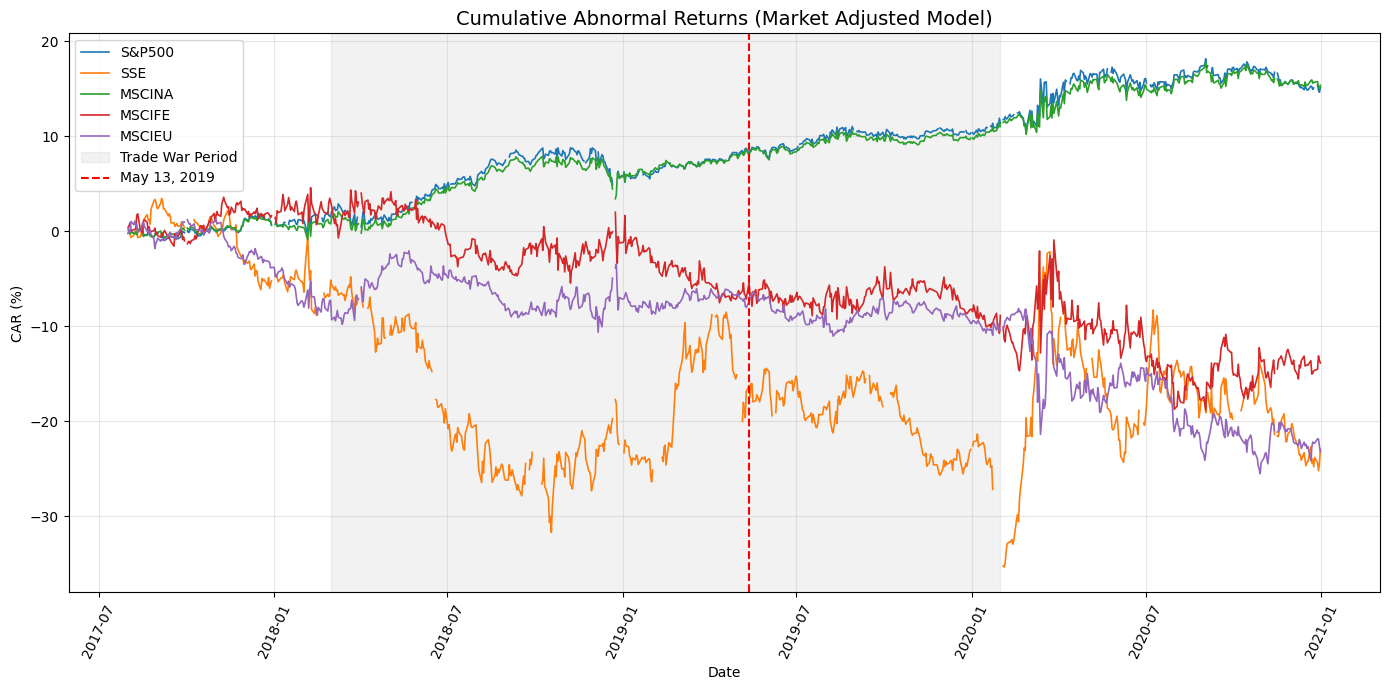

In [ ]:
# Cell 9 — CAR Charts
smpl_start = date.fromisoformat('2017-08-01')
smpl_end = date.fromisoformat('2020-12-31')
smpl_mask = (returns.index >= smpl_start) & (returns.index <= smpl_end)
returns_smpl = returns.loc[smpl_mask]

fig, ax = plt.subplots(figsize=(14, 7))

for col in INDICES:
    ar = returns_smpl[col] - returns_smpl[BENCHMARK]
    car = ar.cumsum()
    ax.plot(car.index, car.values, label=col, linewidth=1.2)

ax.axvspan(
    pd.Timestamp('2018-03-01'), pd.Timestamp('2020-01-31'),
    alpha=0.1, color='gray', label='Trade War Period'
)
ax.axvline(
    pd.Timestamp('2019-05-13'),
    color='red', linestyle='--', linewidth=1.5, label='May 13, 2019'
)

ax.set_title('Cumulative Abnormal Returns (Market Adjusted Model)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('CAR (%)')
ax.legend(loc='best', fontsize=10)
ax.tick_params(axis='x', rotation=65)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 10 — GARCH Sub-Period Analysis
SUB_PERIODS = {
    'Pre-event': (date.fromisoformat('2017-08-01'), date.fromisoformat('2018-02-28')),
    'Event': (date.fromisoformat('2018-03-01'), date.fromisoformat('2020-01-31')),
}

print("=" * 60)
print("GARCH SUB-PERIOD ANALYSIS")
print("=" * 60)
print("Full model: AR(1)–AR(9) + GARCH(1,1)")
print("Refined model: significant AR lags only + GARCH(1,1)")

for col in INDICES:
    print(f"\n{'='*60}")
    print(f"INDEX: {col.upper()}")
    print(f"{'='*60}")

    for period_name, (p_start, p_end) in SUB_PERIODS.items():
        print(f"\n  --- {period_name} ({p_start} to {p_end}) ---")
        try:
            full_res, refined_res = fit_garch_subperiod(
                returns, col, p_start, p_end, max_ar_lags=9
            )
            print(f"\n  Full Model Summary:")
            print(full_res.summary().tables[1])
            print(f"\n  Refined Model Summary:")
            print(refined_res.summary().tables[1])
        except Exception as e:
            print(f"  GARCH estimation failed: {e}")

GARCH SUB-PERIOD ANALYSIS
Full model: AR(1)–AR(9) + GARCH(1,1)
Refined model: significant AR lags only + GARCH(1,1)

INDEX: S&P500

  --- Pre-event (2017-08-01 to 2018-02-28) ---

  Full Model Summary:
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.1315  4.851e-02      2.710  6.730e-03  [3.638e-02,  0.227]
S&P500[1]     -0.0579  8.859e-02     -0.654      0.513    [ -0.232,  0.116]
S&P500[2]     -0.0930      0.127     -0.734      0.463    [ -0.341,  0.155]
S&P500[3]      0.0355      0.113      0.314      0.754    [ -0.186,  0.257]
S&P500[4]     -0.0346      0.112     -0.309      0.757    [ -0.254,  0.185]
S&P500[5]      0.0837      0.109      0.765      0.444    [ -0.131,  0.298]
S&P500[6]      0.0671  7.549e-02      0.888      0.374 [-8.089e-02,  0.215]
S&P500[7]      0.1572  8.116e-02      

In [ ]:
# Cell 11 — Export to Excel
import os

EXPORT_DIR = os.path.dirname(DATA_PATH)

all_tables = {}
all_tables.update(build_all_tables(results_am, 'AM'))
all_tables.update(build_all_tables(results_mm, 'MM'))
all_tables.update(build_all_tables(results_garch, 'GARCH'))

export_path = os.path.join(EXPORT_DIR, 'event_study_results.xlsx')
export_to_excel(all_tables, export_path)
print(f"Results exported to: {export_path}")

Exported 15 sheets to /content/drive/MyDrive/Thảo/data/indices/event_study_results.xlsx
Results exported to: /content/drive/MyDrive/Thảo/data/indices/event_study_results.xlsx
